# 01 — Análisis de `sample_table.csv` para el diseño del KG (EMPKG-lite v0)

Este notebook analiza el artefacto **ya procesado** `data/processed/sample_table.csv`,
generado por `scripts/build_sample_table.py`. El objetivo es tomar decisiones de
modelado del Knowledge Graph basadas en los datos reales del artefacto final, no en
supuestos ni en los números observados sobre el mapping file crudo.

**Relación con el resto del proyecto:**

- `00_explore_biom.ipynb` exploró el BIOM y el mapping file *crudos*.
- Este notebook (`01_analyze_sample_table.ipynb`) analiza el resultado *ya limpio y
  cruzado* de ambos (`sample_table.csv`), para no repetir aquí trabajo de limpieza.
- Las conclusiones de este notebook alimentan directamente `docs/kg_design_v0.md`.

**Qué SÍ hace este notebook:**

- Valida la calidad de `sample_table.csv` como base para el KG (unicidad de
  `sample_id`, tipos de datos, rangos plausibles).
- Cuantifica cardinalidad y cobertura de los campos candidatos a nodo, relación o
  literal RDF.
- Selecciona un subconjunto pequeño y representativo de muestras para el primer
  RDF de prueba.

**Qué NO hace este notebook:**

- No limpia ni normaliza metadatos (eso ya lo hizo `build_sample_table.py`).
- No genera RDF ni Turtle.
- No usa ningún LLM ni mapea a ontologías externas (ENVO, GAZ, NCBITaxon). Eso
  corresponde a la Fase 1D, todavía aplazada hasta cerrar el diseño v0.

## 1. Imports y configuración

Los mismos imports base que en `00_explore_biom.ipynb`. `matplotlib` es opcional:
el análisis tabular no depende de él, pero un par de gráficos de cobertura y
distribución son útiles para la memoria del TFG.

In [95]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)

## 2. Rutas del proyecto

Misma lógica de detección de raíz que en `00_explore_biom.ipynb`, para que el
notebook funcione tanto si se ejecuta desde `notebooks/` como desde la raíz del
repositorio.

In [96]:
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

SAMPLE_TABLE_PATH = PROJECT_ROOT / "data" / "processed" / "sample_table.csv"
SAMPLES_OUT_DIR = PROJECT_ROOT / "data" / "samples"

print(f"Raíz del proyecto : {PROJECT_ROOT}")
print(f"sample_table.csv  : {SAMPLE_TABLE_PATH}")
print(f"Existe            : {SAMPLE_TABLE_PATH.exists()}")

if not SAMPLE_TABLE_PATH.exists():
    raise FileNotFoundError(
        "No se encuentra sample_table.csv. "
        "Ejecuta antes 'python scripts/build_sample_table.py'."
    )

Raíz del proyecto : /home/oier/EMPKG
sample_table.csv  : /home/oier/EMPKG/data/processed/sample_table.csv
Existe            : True


## 3. Carga y verificación de dimensiones

A diferencia del mapping file crudo, aquí **no** forzamos `dtype=str`: el CSV ya
pasó por `pd.to_numeric()` en `build_sample_table.py`, así que dejamos que pandas
infiera los tipos y los comprobamos después en la sección 5.

Esperado: 2.000 filas × 23 columnas (más el índice `sample_id`, que no cuenta
como columna de datos).

In [97]:
df = pd.read_csv(SAMPLE_TABLE_PATH, index_col="sample_id")

print(f"Shape: {df.shape}")
print(f"  → {df.shape[0]:,} muestras  ×  {df.shape[1]:,} columnas "
      f"(sin contar el índice sample_id)")
print()
print("Columnas:")
print(df.columns.tolist())

df.head()

Shape: (2000, 23)
  → 2,000 muestras  ×  23 columnas (sin contar el índice sample_id)

Columnas:
['study_id', 'empo_1', 'empo_2', 'empo_3', 'env_biome', 'env_feature', 'env_material', 'envo_biome_0', 'envo_biome_1', 'envo_biome_2', 'envo_biome_3', 'country', 'latitude_deg', 'longitude_deg', 'depth_m', 'altitude_m', 'elevation_m', 'temperature_deg_c', 'ph', 'salinity_psu', 'oxygen_mg_per_l', 'biom_total_reads', 'biom_observed_asvs']


,study_id,empo_1,empo_2,empo_3,env_biome,env_feature,env_material,envo_biome_0,envo_biome_1,envo_biome_2,envo_biome_3,country,latitude_deg,longitude_deg,depth_m,altitude_m,elevation_m,temperature_deg_c,ph,salinity_psu,oxygen_mg_per_l,biom_total_reads,biom_observed_asvs
sample_id,,,,,,,,,,,,,,,,,,,,,,,
550.L1S116.s.1.sequence,550,Host-associated,Animal,Animal distal gut,urban biome,human-associated habitat,feces,biome,terrestrial biome,anthropogenic terrestrial biome,dense settlement biome,GAZ:United States of America,40.015,-105.271,0.0,0.0,1624.1,NaN,NaN,NaN,NaN,5000,91
550.L1S119.s.1.sequence,550,Host-associated,Animal,Animal distal gut,urban biome,human-associated habitat,feces,biome,terrestrial biome,anthropogenic terrestrial biome,dense settlement biome,GAZ:United States of America,40.015,-105.271,0.0,0.0,1624.1,NaN,NaN,NaN,NaN,5000,77
550.L1S164.s.1.sequence,550,Host-associated,Animal,Animal distal gut,urban biome,human-associated habitat,feces,biome,terrestrial biome,anthropogenic terrestrial biome,dense settlement biome,GAZ:United States of America,40.015,-105.271,0.0,0.0,1624.1,NaN,NaN,NaN,NaN,5000,104
550.L1S194.s.1.sequence,550,Host-associated,Animal,Animal distal gut,urban biome,human-associated habitat,feces,biome,terrestrial biome,anthropogenic terrestrial biome,dense settlement biome,GAZ:United States of America,40.015,-105.271,0.0,0.0,1624.1,NaN,NaN,NaN,NaN,5000,115
550.L1S20.s.1.sequence,550,Host-associated,Animal,Animal distal gut,urban biome,human-associated habitat,feces,biome,terrestrial biome,anthropogenic terrestrial biome,dense settlement biome,GAZ:United States of America,40.015,-105.271,0.0,0.0,1624.1,NaN,NaN,NaN,NaN,5000,80


## 4. Validación de `sample_id`

`sample_id` será la clave de la futura URI del nodo `empkg:Sample`. 
Antes de asumir que sirve como tal, comprobamos formalmente que es único y no nulo — el mismo tipo de comprobación que ya se hizo entre BIOM y mapping file en `00_explore_biom.ipynb`, pero ahora sobre el artefacto final.

In [98]:
n_total = df.shape[0]
n_unique_ids = df.index.nunique()
n_null_ids = int(df.index.isna().sum())

print(f"Total de filas           : {n_total:,}")
print(f"sample_id únicos         : {n_unique_ids:,}")
print(f"sample_id nulos          : {n_null_ids:,}")
print(f"¿Índice único?           : {df.index.is_unique}")


print("\nEjemplos de sample_id:")
for sid in df.index[:5]:
    print(f"  {sid}")

assert df.index.is_unique, "sample_id no es único: revisar build_sample_table.py"
assert n_null_ids == 0, "Hay sample_id nulos: revisar build_sample_table.py"

print("\nOK: sample_id es válido como clave del futuro nodo empkg:Sample.")

Total de filas           : 2,000
sample_id únicos         : 2,000
sample_id nulos          : 0
¿Índice único?           : True

Ejemplos de sample_id:
  550.L1S116.s.1.sequence
  550.L1S119.s.1.sequence
  550.L1S164.s.1.sequence
  550.L1S194.s.1.sequence
  550.L1S20.s.1.sequence

OK: sample_id es válido como clave del futuro nodo empkg:Sample.


## 5. Revisión de tipos de datos

Comprobamos que las columnas que deberían ser numéricas (coordenadas, medidas
fisicoquímicas, estadísticas del BIOM) efectivamente lo son tras pasar por
`build_sample_table.py`. Si alguna quedara como `object`, sería señal de que
`pd.to_numeric(errors="coerce")` dejó restos no convertidos silenciosamente.

In [99]:
EXPECTED_NUMERIC = [
    "study_id",
    "latitude_deg", "longitude_deg", "depth_m", "altitude_m", "elevation_m",
    "temperature_deg_c", "ph", "salinity_psu", "oxygen_mg_per_l",
    "biom_total_reads", "biom_observed_asvs",
]

print("Tipos de dato por columna:\n")
print(df.dtypes)

non_numeric_expected = [
    col for col in EXPECTED_NUMERIC
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col])
]

print("\nColumnas que deberían ser numéricas pero no lo son:")
print(non_numeric_expected if non_numeric_expected else "  Ninguna. OK.")

Tipos de dato por columna:

study_id                int64
empo_1                    str
empo_2                    str
empo_3                    str
env_biome                 str
env_feature               str
env_material              str
envo_biome_0              str
envo_biome_1              str
envo_biome_2              str
envo_biome_3              str
country                   str
latitude_deg          float64
longitude_deg         float64
depth_m               float64
altitude_m            float64
elevation_m           float64
temperature_deg_c     float64
ph                    float64
salinity_psu          float64
oxygen_mg_per_l       float64
biom_total_reads        int64
biom_observed_asvs      int64
dtype: object

Columnas que deberían ser numéricas pero no lo son:
  Ninguna. OK.


## 6. Cobertura de campos clave

Repetimos el cálculo de cobertura que ya se hizo sobre el mapping file crudo en
`00_explore_biom.ipynb`, pero ahora sobre `sample_table.csv`. Los porcentajes
deberían ser muy similares (el join fue `inner` y no introdujo nulos nuevos),
pero conviene confirmarlo explícitamente antes de tomar decisiones de diseño
sobre este artefacto.

In [100]:
coverage = pd.DataFrame({
    "column": df.columns,
    "n_filled": [int(df[col].notna().sum()) for col in df.columns],
    "n_total": n_total,
})
coverage["pct_filled"] = (coverage["n_filled"] / coverage["n_total"] * 100).round(1)
coverage = coverage.sort_values("pct_filled").reset_index(drop=True)

coverage

,column,n_filled,n_total,pct_filled
0,oxygen_mg_per_l,26,2000,1.3
1,salinity_psu,121,2000,6.0
2,ph,284,2000,14.2
3,temperature_deg_c,411,2000,20.5
4,envo_biome_3,1443,2000,72.2
5,depth_m,1750,2000,87.5
6,altitude_m,1919,2000,96.0
7,envo_biome_2,1967,2000,98.4
8,elevation_m,1981,2000,99.1
9,latitude_deg,1998,2000,99.9


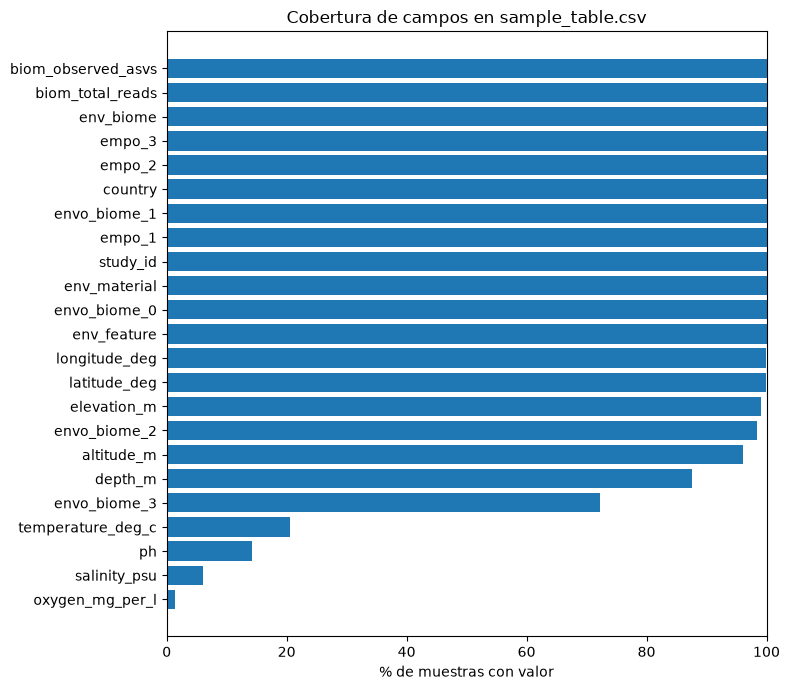

In [101]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(coverage["column"], coverage["pct_filled"])
ax.set_xlabel("% de muestras con valor")
ax.set_title("Cobertura de campos en sample_table.csv")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## 7. Distribución de `empo_1`, `empo_2`, `empo_3`

Además de la distribución de cada nivel, comprobamos la **consistencia
jerárquica**: si cada valor de `empo_3` corresponde siempre al mismo `empo_2` y
`empo_1`, entonces `empo_3` puede usarse como identificador único de un nodo
`EMPOCategory` sin necesidad de arrastrar el path completo (`empo_1` +
`empo_2` + `empo_3`) en la URI.

In [102]:
for level in ["empo_1", "empo_2", "empo_3"]:
    print(f"\n{level} ({df[level].nunique()} categorías):")
    print(df[level].value_counts(dropna=False))


empo_1 (2 categorías):
empo_1
Host-associated    1019
Free-living         981
Name: count, dtype: int64

empo_2 (4 categorías):
empo_2
Animal        640
Non-saline    595
Saline        386
Plant         379
Name: count, dtype: int64

empo_3 (17 categorías):
empo_3
Animal surface           143
Soil (non-saline)        129
Water (non-saline)       129
Animal distal gut        128
Animal corpus            128
Water (saline)           128
Sediment (saline)        128
Sediment (non-saline)    128
Surface (non-saline)     128
Plant surface            128
Plant rhizosphere        128
Animal proximal gut      128
Plant corpus             123
Surface (saline)         117
Animal secretion         113
Aerosol (non-saline)      81
Hypersaline (saline)      13
Name: count, dtype: int64


In [103]:
print("¿empo_3 mapea siempre al mismo empo_2 y empo_1?\n")

empo3_consistency = df.groupby("empo_3")[["empo_1", "empo_2"]].nunique()
print(empo3_consistency)

inconsistentes = empo3_consistency[
    (empo3_consistency["empo_1"] > 1) | (empo3_consistency["empo_2"] > 1)
]

if inconsistentes.empty:
    print("\nOK: cada empo_3 corresponde a un único empo_1/empo_2. "
          "empo_3 puede usarse como identificador de EMPOCategory "
          "sin ambigüedad.")
else:
    print("\nAVISO: hay valores de empo_3 asociados a más de un empo_1/empo_2:")
    print(inconsistentes)

¿empo_3 mapea siempre al mismo empo_2 y empo_1?

                       empo_1  empo_2
empo_3                               
Aerosol (non-saline)        1       1
Animal corpus               1       1
Animal distal gut           1       1
Animal proximal gut         1       1
Animal secretion            1       1
Animal surface              1       1
Hypersaline (saline)        1       1
Plant corpus                1       1
Plant rhizosphere           1       1
Plant surface               1       1
Sediment (non-saline)       1       1
Sediment (saline)           1       1
Soil (non-saline)           1       1
Surface (non-saline)        1       1
Surface (saline)            1       1
Water (non-saline)          1       1
Water (saline)              1       1

OK: cada empo_3 corresponde a un único empo_1/empo_2. empo_3 puede usarse como identificador de EMPOCategory sin ambigüedad.


## 8. Análisis de `env_biome`, `env_feature`, `env_material`

Estos tres campos son texto libre (o semi-controlado) según `annotations.md`.
Medimos su cardinalidad real y su relación con `empo_2`/`empo_3`: si aportan
información redundante con EMPO, su peso en el diseño v0 es menor; si aportan
variedad adicional, son el material principal para la futura armonización con
LLM (Fase 1D), pero **aquí solo se observa, no se normaliza**.

In [104]:
for col in ["env_biome", "env_feature", "env_material"]:
    n_unique = df[col].nunique()
    n_filled = df[col].notna().sum()
    print(f"{col:<15} {n_unique:>4} valores únicos de {n_filled:,} muestras con dato")

print("\nValores únicos de env_material (primeros 30, orden alfabético):")
print(sorted(df["env_material"].dropna().unique())[:30])

env_biome         40 valores únicos de 2,000 muestras con dato
env_feature       84 valores únicos de 2,000 muestras con dato
env_material      40 valores únicos de 2,000 muestras con dato

Valores únicos de env_material (primeros 30, orden alfabético):
['air', 'animal habitation', 'anthropogenic environmental material', 'avian egg product', 'biofilm', 'biofilm material', 'bodily fluid', 'brackish water', 'bulk soil', 'carcass', 'coastal water', 'contaminated sediment', 'dust', 'estuary sediment', 'estuary water', 'excreta', 'feces', 'fresh water', 'hypersaline water', 'lake sediment', 'marine sediment', 'microbial mat', 'microbial mat material', 'mucus', 'ocean water', 'organic material', 'rhizosphere', 'saline lake sediment', 'saline water', 'saliva']


In [105]:
print("Combinaciones (empo_2, env_material):\n")
print(
    df.groupby(["empo_2", "env_material"], dropna=False).size()
    .sort_values(ascending=False)
    .head(25)
)


Combinaciones (empo_2, env_material):

empo_2      env_material     
Plant       organic material     220
Animal      organic material     186
Non-saline  fresh water          129
Animal      feces                117
Non-saline  soil                 117
Saline      sea water             94
            biofilm               91
            marine sediment       90
Non-saline  air                   81
Plant       rhizosphere           78
Animal      sebum                 76
            saliva                73
            excreta               71
            mucus                 65
Plant       biofilm               64
Non-saline  lake sediment         52
            sediment              41
            stream sediment       35
            biofilm               30
            dust                  29
Saline      travertine            29
Non-saline  microbial mat         28
Animal      avian egg product     26
Plant       animal habitation     17
Animal      bodily fluid          16
dtype:

In [106]:
print("Verificando valores que abarcan los campos envo_biome_*:\n")

for col in ["envo_biome_0","envo_biome_1","envo_biome_2","envo_biome_3"]: 
    print(df[col].value_counts(dropna=False))

Verificando valores que abarcan los campos envo_biome_*:

envo_biome_0
biome    2000
Name: count, dtype: int64
envo_biome_1
terrestrial biome    1105
aquatic biome         895
Name: count, dtype: int64
envo_biome_2
anthropogenic terrestrial biome    889
marine biome                       535
freshwater biome                   335
forest biome                        69
shrubland biome                     66
NaN                                 33
tundra biome                        28
desert biome                        13
woodland biome                      13
grassland biome                     12
mangrove biome                       7
Name: count, dtype: int64
envo_biome_3
NaN                            557
dense settlement biome         484
cropland biome                 272
marine benthic biome           184
freshwater lake biome          160
village biome                   94
freshwater river biome          85
rangeland biome                 38
broadleaf forest biome          29
ma

## 9. Análisis de coordenadas geográficas

Validamos rango plausible (`latitude_deg` en [-90, 90], `longitude_deg` en
[-180, 180]) y, sobre todo, comprobamos si hay **coordenadas duplicadas**: si
muchas muestras comparten exactamente el mismo punto GPS, eso es evidencia
empírica a favor de modelar `Location` como un nodo compartido y deduplicado
en vez de una relación 1:1 con cada `Sample`. Es una de las decisiones abiertas
en `annotations.md`.

In [107]:
lat_out_of_range = df[(df["latitude_deg"] < -90) | (df["latitude_deg"] > 90)]
lon_out_of_range = df[(df["longitude_deg"] < -180) | (df["longitude_deg"] > 180)]

print(f"Muestras sin latitud  : {int(df['latitude_deg'].isna().sum())}")
print(f"Muestras sin longitud : {int(df['longitude_deg'].isna().sum())}")
print(f"Latitudes fuera de rango  : {len(lat_out_of_range)}")
print(f"Longitudes fuera de rango : {len(lon_out_of_range)}")

Muestras sin latitud  : 2
Muestras sin longitud : 2
Latitudes fuera de rango  : 0
Longitudes fuera de rango : 0


In [108]:
coords = df[["latitude_deg", "longitude_deg"]].dropna()
n_coord_duplicadas = int(coords.duplicated().sum())

print(f"Muestras con coordenadas válidas: {len(coords):,}")
print(f"Muestras con coordenadas duplicadas (comparten lat/lon exactas): "
      f"{n_coord_duplicadas:,} de {len(coords):,}")

print("\nGrupos de coordenadas más compartidos (top 10):")
print(
    coords.groupby(["latitude_deg", "longitude_deg"]).size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nDistribución por país (top 15):")
print(df["country"].value_counts().head(15))

Muestras con coordenadas válidas: 1,998
Muestras con coordenadas duplicadas (comparten lat/lon exactas): 1,501 de 1,998

Grupos de coordenadas más compartidos (top 10):
latitude_deg  longitude_deg
18.220000     -65.990000       76
35.117000      138.937000      74
40.015000     -105.271000      69
32.720000     -117.160000      64
41.880000     -87.630000       58
50.010000      8.230000        43
39.740000     -104.980000      42
12.109750     -68.956360       35
11.035278      63.845556       32
48.360000     -124.570000      25
dtype: int64

Distribución por país (top 15):
country
GAZ:United States of America    1021
GAZ:Australia                    140
GAZ:Puerto Rico                  115
GAZ:Venezuela                     86
GAZ:Japan                         74
GAZ:North Atlantic Ocean          62
GAZ:Germany                       55
GAZ:Italy                         50
GAZ:Curacao Island                35
GAZ:Norway                        33
GAZ:Spain                         26
GA

## 10. Análisis de campos fisicoquímicos

`ph`, `temperature_deg_c`, `salinity_psu` y `oxygen_mg_per_l` ya se sabía por
`00_explore_biom.ipynb` que tienen cobertura baja (14,2%, 20,5%, 6,0% y 1,3%
respectivamente, sobre el mapping crudo). Aquí confirmamos esos números sobre
`sample_table.csv` y comprobamos además si **coinciden en las mismas
muestras**: si una muestra con pH casi siempre tiene también temperatura, estos
campos pueden tratarse como un bloque coherente de propiedades; si no, hay que
modelarlos como independientes.

In [109]:
FISICOQUIMICOS = ["ph", "temperature_deg_c", "salinity_psu", "oxygen_mg_per_l"]

print(df[FISICOQUIMICOS].describe().round(2))

ph_fuera_rango = df[(df["ph"].notna()) & ((df["ph"] < 0) | (df["ph"] > 14))]
print(f"\nMuestras con pH fuera de [0, 14]: {len(ph_fuera_rango)}")

           ph  temperature_deg_c  salinity_psu  oxygen_mg_per_l
count  284.00             411.00        121.00            26.00
mean     8.12              18.49         24.96            10.94
std      1.68              16.67         12.95             1.68
min      3.45             -15.00          0.04             8.40
25%      7.30               9.71          7.44             9.30
50%      8.06              15.24         31.40            10.65
75%      9.00              20.21         34.97            12.14
max     12.30              91.00         37.07            13.80

Muestras con pH fuera de [0, 14]: 0


In [110]:
presencia = df[FISICOQUIMICOS].notna()

print("Muestras con dato, por campo:")
print(presencia.sum())

print(f"\nMuestras con TODOS los campos fisicoquímicos presentes: "
      f"{int(presencia.all(axis=1).sum())}")
print(f"Muestras con AL MENOS UNO presente: {int(presencia.any(axis=1).sum())}")

Muestras con dato, por campo:
ph                   284
temperature_deg_c    411
salinity_psu         121
oxygen_mg_per_l       26
dtype: int64

Muestras con TODOS los campos fisicoquímicos presentes: 13
Muestras con AL MENOS UNO presente: 512


## 11. Columnas candidatas a nodos, relaciones y literales

Tabla de decisión construida a partir de los resultados anteriores, no a
priori. La columna `candidato_propuesto` es una **propuesta de partida**
razonada según cardinalidad y cobertura — revisar manualmente antes de
trasladarla a `docs/kg_design_v0.md`, especialmente para `empo_1`/`empo_2`
(¿nodo o literal?) y `country` (¿literal o futuro nodo GAZ?).

In [111]:
CANDIDATOS = {
    "study_id":           "relación (Sample -> belongsToStudy -> Study)",
    "empo_1":              "literal de EMPOCategory o futuro nodo jerárquico EMPO",
    "empo_2":              "literal de EMPOCategory o futuro nodo jerárquico EMPO",
    "empo_3":              "nodo EMPOCategory principal",
    "env_biome":           "literal / futuro mapeo ENVO (Fase 1D)",
    "env_feature":         "literal / futuro mapeo ENVO (Fase 1D)",
    "env_material":        "literal / futuro mapeo ENVO (Fase 1D)",
    "envo_biome_0":        "literal / futuro mapeo ENVO (Fase 1D)",
    "envo_biome_1":        "literal / futuro mapeo ENVO (Fase 1D)",
    "envo_biome_2":        "literal / futuro mapeo ENVO (Fase 1D)",
    "envo_biome_3":        "literal / futuro mapeo ENVO (Fase 1D)",
    "country":             "propiedad de Location / futuro mapeo GAZ",
    "latitude_deg":        "literal numérico de Location",
    "longitude_deg":       "literal numérico de Location",
    "depth_m":             "literal numérico de Location",
    "altitude_m":          "literal numérico de Location",
    "elevation_m":         "literal numérico de Location",
    "temperature_deg_c":   "literal numérico de Sample",
    "ph":                  "literal numérico de Sample",
    "salinity_psu":        "literal numérico de Sample",
    "oxygen_mg_per_l":     "literal numérico de Sample",
    "biom_total_reads":    "literal numérico de Sample",
    "biom_observed_asvs":  "literal numérico de Sample",
}

resumen = pd.DataFrame({
    "cardinalidad": {col: int(df[col].nunique()) for col in df.columns},
    "pct_cobertura": {col: round(df[col].notna().mean() * 100, 1) for col in df.columns},
})
resumen["candidato_propuesto"] = resumen.index.map(
    lambda c: CANDIDATOS.get(c, "revisar manualmente")
)

resumen.sort_values("pct_cobertura", ascending=False)

,cardinalidad,pct_cobertura,candidato_propuesto
study_id,95,100.0,relación (Sample -> belongsToStudy -> Study)
empo_1,2,100.0,literal de EMPOCategory o futuro nodo jerárqui...
empo_2,4,100.0,literal de EMPOCategory o futuro nodo jerárqui...
empo_3,17,100.0,nodo EMPOCategory principal
env_biome,40,100.0,literal / futuro mapeo ENVO (Fase 1D)
env_feature,84,100.0,literal / futuro mapeo ENVO (Fase 1D)
env_material,40,100.0,literal / futuro mapeo ENVO (Fase 1D)
envo_biome_0,1,100.0,literal / futuro mapeo ENVO (Fase 1D)
envo_biome_1,2,100.0,literal / futuro mapeo ENVO (Fase 1D)
country,41,100.0,propiedad de Location / futuro mapeo GAZ


## 12. Selección de subconjunto para el primer RDF de prueba

Criterio explícito y reproducible (semilla fija), no una muestra aleatoria sin
justificar:

1. Solo muestras con coordenadas válidas (`latitude_deg`, `longitude_deg`).
2. Cobertura de campos: se prioriza el número de campos rellenos por muestra
   (mismo criterio `n_campos_rellenos` que en `00_explore_biom.ipynb`).
3. Diversidad: al menos una muestra representativa por cada categoría `empo_3`
   presente entre las candidatas, para que el primer RDF de prueba cubra
   varios tipos de entorno y no solo el caso más fácil.

El resultado se exporta a `data/samples/kg_v0_test_samples.csv`, para que el
futuro script de generación de RDF sea determinista y trazable.

In [112]:
CAMPOS_PARA_COMPLETITUD = [
    "empo_1", "empo_2", "empo_3",
    "env_biome", "env_feature", "env_material",
    "envo_biome_0", "envo_biome_1", "envo_biome_2", "envo_biome_3",
    "country", "latitude_deg", "longitude_deg", "depth_m", "altitude_m", "elevation_m",
    "temperature_deg_c", "ph", "salinity_psu", "oxygen_mg_per_l",
]

df["n_campos_rellenos"] = df[CAMPOS_PARA_COMPLETITUD].notna().sum(axis=1)

coords_validas = df["latitude_deg"].notna() & df["longitude_deg"].notna()
candidatas = df[coords_validas].copy()

print(f"Muestras candidatas (con coordenadas válidas): {len(candidatas):,} de {len(df):,}")

Muestras candidatas (con coordenadas válidas): 1,998 de 2,000


In [113]:
N_POR_CATEGORIA = 1
N_MAX = 17
SEED = 67

seleccion = []
for empo3_val, grupo in candidatas.groupby("empo_3"):
    top = grupo.sort_values("n_campos_rellenos", ascending=False).head(N_POR_CATEGORIA)
    seleccion.append(top)

test_samples = pd.concat(seleccion).sort_values("n_campos_rellenos", ascending=False)

if len(test_samples) > N_MAX:
    test_samples = test_samples.sample(n=N_MAX, random_state=SEED)

print(f"Muestras seleccionadas para el RDF de prueba: {len(test_samples)}")
print(f"Categorías empo_3 representadas: {test_samples['empo_3'].nunique()}")

test_samples[
    ["empo_3", "country", "latitude_deg", "longitude_deg", "ph", "n_campos_rellenos"]
]

Muestras seleccionadas para el RDF de prueba: 17
Categorías empo_3 representadas: 17


,empo_3,country,latitude_deg,longitude_deg,ph,n_campos_rellenos
sample_id,,,,,,
1001.SKB7,Plant rhizosphere,GAZ:United States of America,33.194000,-117.241000,6.940,19
1883.2011.491.Crump.Artic.LTREB.main.lane4.NoIndex,Water (saline),GAZ:United States of America,70.066017,-143.190383,7.800,19
1041.M041.100,Water (non-saline),GAZ:United States of America,44.737000,-86.721000,8.203,19
1001.SKD6,Soil (non-saline),GAZ:United States of America,33.194000,-117.241000,6.800,19
807.C.F.10.b,Sediment (non-saline),GAZ:United States of America,45.942894,-106.949183,8.690,18
678.OA.mesocosm.362,Sediment (saline),GAZ:England,50.338000,-4.148000,8.030,18
895.Puhimau.mat.3,Surface (non-saline),GAZ:United States of America,19.389000,-155.250000,3.770,18
804.3869.1446,Surface (saline),GAZ:North Atlantic Ocean,30.123934,-42.120154,10.100,18
2300.BB.4087.anus,Animal distal gut,GAZ:United States of America,47.937130,-95.986280,NaN,17


In [114]:
SAMPLES_OUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = SAMPLES_OUT_DIR / "kg_v0_test_samples.csv"

test_samples.drop(columns=["n_campos_rellenos"]).to_csv(output_path, index=True)

print(f"Guardado: {output_path}")
print(f"Filas: {test_samples.shape[0]}, columnas: {test_samples.shape[1] - 1} (+ sample_id)")

Guardado: /home/oier/EMPKG/data/samples/kg_v0_test_samples.csv
Filas: 17, columnas: 23 (+ sample_id)


## 13. Conclusiones para `docs/kg_design_v0.md`

**Validez de `sample_id`**

Cada fila de `sample_table.csv` representa una muestra EMP única. Por ende, `sample_id` puede usarse como identificador principal de cada nodo Sample. Para construir URIs RDF habrá que sanitizar los valores, porque un amplio porcentaje de IDs contienen puntos u otros caracteres que convendría normalizar.
sample_id → empkg:Sample
550.L1S116.s.1.sequence → empkg:sample/550_L1S116_s_1_sequence

**Tipos de datos** 

Todas las columnas numéricas esperadas son numéricas, sin errores en la conversión de `build_sample_table.py`.

**Cobertura de campos clave** 

Todos los campos salvo los campos fisicoquímicos (`ph`, `temperature_deg_c`, `salinity_psu`, `oxygen_mg_per_l`) tienen una cobertura >50%.

| column |	n_filled |	n_total |	pct_filled |
| :------- | :------: | -------: | -------: |
| oxygen_mg_per_l |	26 |	2000 |	1.3 |
| salinity_psu |	121 |	2000 |	6.0 |
| ph |	284 |	2000 |	14.2 |
| temperature_deg_c |	411 |	2000 |	20.5 |
| envo_biome_3 |	1443 |	2000 |	72.2 |
| depth_m |	1750 |	2000 |	87.5 |
| altitude_m |	1919 |	2000 |	96.0 |
| envo_biome_2 |	1967 |	2000 |	98.4 |
| elevation_m |	1981 |	2000 |	99.1 |
| latitude_deg |	1998 |	2000 |	99.9 |
| longitude_deg |	1998 |	2000 |	99.9 |
| env_feature |	2000 |	2000 |	100.0 |
| envo_biome_0 |	2000 |	2000 |	100.0 |
| env_material |	2000 |	2000 |	100.0 |
| study_id |	2000 |	2000 |	100.0 |
| empo_1 |	2000 |	2000 |	100.0 |
| envo_biome_1 |	2000 |	2000 |	100.0 |
| country |	2000 |	2000 |	100.0 |
| empo_2 |	2000 |	2000 |	100.0 |
| empo_3 |	2000 |	2000 |	100.0 |
| env_biome |	2000 |	2000 |	100.0 |
| biom_total_reads |	2000 |	2000 |	100.0 |
| biom_observed_asvs |	2000 |	2000 |	100.0 |

**Jerarquía EMPO**

Los campos `empo_1`, `empo_2` y `empo_3` forman una clasificación ambiental jerárquica, completa y consistente. Dado que cada valor de `empo_3` pertenece siempre a un único `empo_2` y a un único `empo_1`, `empo_3` puede usarse como categoría ambiental principal de cada muestra en el KG v0.

Para evitar confusiones con el campo `env_feature`, vamos a modelar estas categorías como nodos empkg:EMPOCategory en vez de EnvironmentalFeature. En nuestra versión inicial del KG, cada muestra se conectará a un nodo empo_3, y conservará como propiedades sus niveles superiores empo_2 y empo_1.
```text
Sample ──hasEMPOCategory──> EMPOCategory
empo_1
empo_2
empo_3
```

**`env_biome`/`env_feature`/`env_material`**

Los campos env_biome, env_feature y env_material tienen cobertura completa para las 2.000 muestras, pero mayor cardinalidad que EMPO. Esto nos indica que aportan información ambiental más específica que la clasificación EMPO.
```text
empo_3 = Animal corpus
env_biome = polar desert biome
env_feature = cold temperature habitat
env_material = carcass
```
En la versión inicial del KG no se usarán todavía como nodos normalizados, porque contienen texto semi-controlado y pueden generar duplicados semánticos. Se conservarán como literales originales dentro de un nodo `EnvironmentDescription`. Posteriormente serán los principales campos de entrada para el pipeline LLM de armonización con ENVO.
```text
Sample ──hasEnvironmentDescription──> EnvironmentDescription
env_biome
env_feature
env_material
envo_biome_0
envo_biome_1
envo_biome_2
envo_biome_3
```
Los campos envo_biome_* ya contienen una jerarquía ambiental alineada con ENVO, pero en sample_table.csv aparecen como etiquetas textuales, no como URIs ontológicas. En v0 las conservaremos como literales de contexto.
El campo envo_biome_0 solo tiene un valor único 'biome' y no aporta poder discriminativo. El campo envo_biome_1 similar ya que alterna entre los valores 'aquatic' y 'terrestrial'. 
Los campos envo_biome_2 y envo_biome_3 son más útiles para el diseño futuro,
aunque envo_biome_3 tiene cobertura parcial.


**Coordenadas** 

Las coordenadas geográficas tienen una cobertura casi completa y rangos válidos. Además, una proporción alta de muestras comparte coordenadas exactas, lo que nos indica que varias muestras proceden de los mismos sitios de muestreo.
Por ello, en la primera versión del KG  el nodo `Location` se modelará como un nodo reutilizable y deduplicado, no como un nodo exclusivo por Sample. Se construirá con país, latitud, longitud y, cuando estén disponibles, profundidad y elevación.
```text
Sample ──wasCollectedAt──> Location
country
latitude_deg
longitude_deg
depth_m
elevation_m
```

**Campos fisicoquímicos**

Los campos fisicoquímicos tienen baja cobertura y no están presentes de forma consistente en las muestras. Por lo tanto, se modelarán como propiedades opcionales de `Sample`. No se generarán triples para valores ausentes.
El pH tiene valores plausibles dentro del rango [0,14]. La temperatura tiene un máximo de 91 ºC, que concuerda con la muestra de fluido hidrotermal.

**`biom_total_reads`y `biom_observed_asvs`**
El campo biom_total_reads tiene cardinalidad 1 porque todas las muestras fueron rarefaccionadas a 5000 lecturas. Por tanto, en v0 puede conservarse como metadato de control, pero no aporta capacidad de comparación entre muestras.
En cambio, biom_observed_asvs varía entre muestras y puede modelarse como una propiedad numérica de Sample, ya que resume la riqueza observada de ASVs.

**Cardinalidad de `study_id`**

Aunque ya habíamos presuponido `Study` como nodo reutilizable, necesitamos una justificación empírica para para validar esta decisión. 95 estudios sirviendo a 2.000 muestras.
```text
study_id → 95 valores únicos
Muestras por estudio: media ≈ 21, mediana = 10, máximo = 159 (study_id 2382), mínimo = 1
```

**Subconjunto de prueba** 

`data/samples/kg_v0_test_samples.csv`, 17 muestras, las 17 categorías de `empo_3` representadas.
